In [1]:
import sys
sys.path.append('../data')
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('../data/deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from lab_utils_common import dlc
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


In [2]:
X,Y = load_coffee_data()
X.shape

(200, 2)

In [3]:
Y.shape

(200, 1)

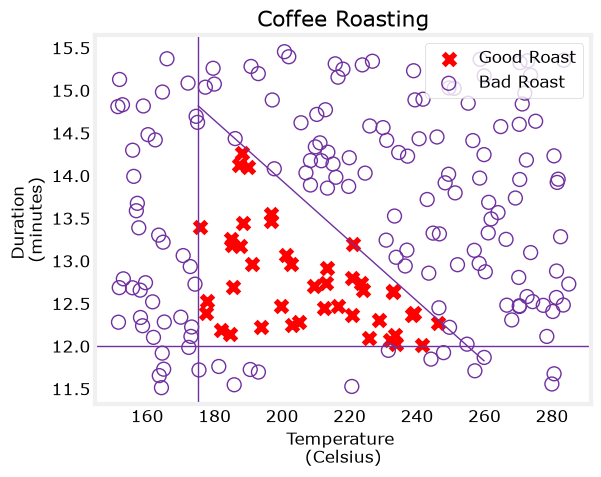

In [4]:
plt_roast(X,Y)

In [5]:
print(f"Temperature Max, min pre normalization : {np.max(X[:,0]) :0.2f} , {np.min(X[:,0]):0.2f}")
print(f"Duration Max, min pre normalization : {np.max(X[:,1]) :0.2f} , {np.min(X[:,1]):0.2f}")

norml = tf.keras.layers.Normalization(axis=1)
norml.adapt(X)
Xn = norml(X)
print(f"Temperature Max, min pre normalization : {np.max(Xn[:,0]) :0.2f} , {np.min(Xn[:,0]):0.2f}")
print(f"Duration Max, min pre normalization : {np.max(Xn[:,1]) :0.2f} , {np.min(Xn[:,1]):0.2f}")

Temperature Max, min pre normalization : 284.99 , 151.32
Duration Max, min pre normalization : 15.45 , 11.51
Temperature Max, min pre normalization : 1.66 , -1.69
Duration Max, min pre normalization : 1.79 , -1.70


In [6]:
Xt = np.tile(Xn,(1000,1))
Yt = np.tile(Y,(1000,1))
print(Xn.shape, Yt.shape)

(200, 2) (200000, 1)


In [7]:
tf.random.set_seed(1234)
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(units=3, activation = 'sigmoid' , name = 'layer1'),
        Dense(units=1, activation = 'sigmoid' , name = 'layer2')
    ]
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
l1 = 2 * 3 + 3 # w1 + b1
l2 = 3 * 1 + 1
print(f"l1: { l1} , l2: { l2}")

l1: 9 , l2: 4


In [10]:
w1,b1 = model.get_layer('layer1').get_weights()
w2,b2 = model.get_layer('layer2').get_weights()
print(f"w1{w1.shape}: {w1} , b1{b1.shape}: {b1}")
print(f"w2{w2.shape}: {w2} , b2{b2.shape}: {b2}")

w1(2, 3): [[ 0.08 -0.42 -0.19]
 [ 0.04  0.09  0.01]] , b1(3,): [0. 0. 0.]
w2(3, 1): [[-1.11]
 [ 0.02]
 [ 0.07]] , b2(1,): [0.]


In [11]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 279us/step - loss: 0.2438
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 289us/step - loss: 0.1218
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 287us/step - loss: 0.1132
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 281us/step - loss: 0.0864
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 286us/step - loss: 0.0190
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 281us/step - loss: 0.0115
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 297us/step - loss: 0.0079
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 286us/step - loss: 0.0056
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 280us/step - loss: 0.0040
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 2s 282us/step - loss: 0.0029


In [12]:
w1,b1 = model.get_layer('layer1').get_weights()
w2,b2 = model.get_layer('layer2').get_weights()
print(f"w1{w1.shape}: {w1} , b1{b1.shape}: {b1}")
print(f"w2{w2.shape}: {w2} , b2{b2.shape}: {b2}")

w1(2, 3): [[ 14.49 -10.4   -0.04]
 [ 12.09  -0.19  -9.08]] , b1(3,): [  1.81 -11.36 -11.37]
w2(3, 1): [[-38.52]
 [-44.44]
 [-40.94]] , b2(1,): [23.41]


In [13]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])

X_testn = norml(X_test)
prediction = model.predict(X_test)
print(f"Prediction : {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediction : [[2.73e-07]
 [2.73e-07]]


In [14]:
yhat = np.zeros_like(prediction)
for i in range(len(prediction)):
    if prediction[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions : {yhat}")

decisions : [[0.]
 [0.]]


In [15]:
yhat = (prediction >= 0.5).astype('int')
print(f"decision : {yhat}")

decision : [[0]
 [0]]


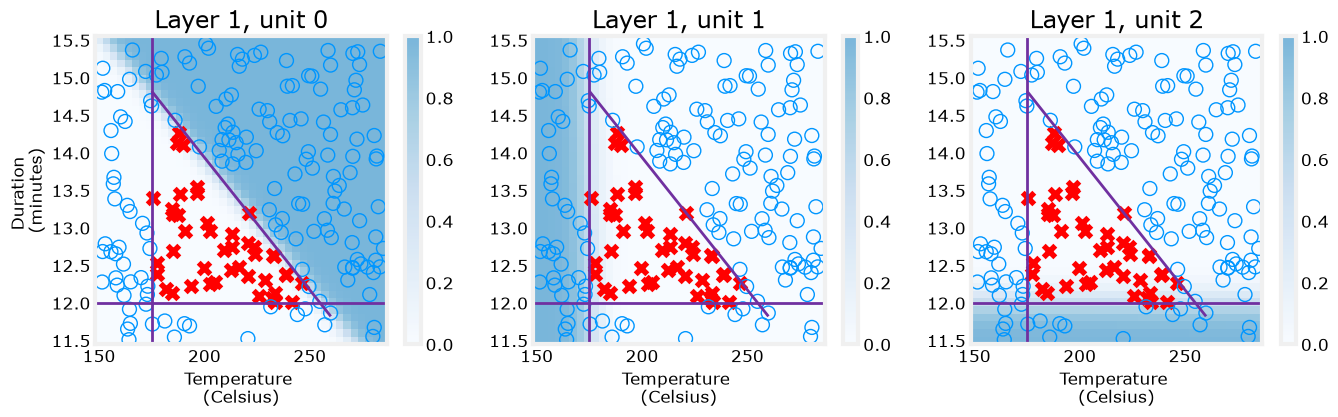

In [16]:
plt_layer(X,Y.reshape(-1,),w1,b1,norml)

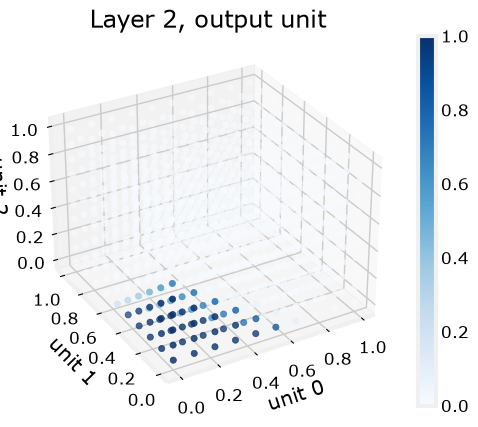

In [17]:
plt_output_unit(w2,b2)